In [1]:
import os, re, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.optimize import curve_fit

h1   = pd.read_csv("HarrisPartI.csv")
h3   = pd.read_csv("HarrisPartIII.csv")



In [28]:
# LaTeX initialisation
# Many LaTeX parameters set to NULL otherwise plots take 84392409432 years to initialise and run

plt.savefig("amr_plot.png", dpi=300, bbox_inches="tight")
plt.rcParams['figure.dpi'] = 150
plt.rcParams["text.usetex"] = False
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["font.family"] = "serif"
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
})

<Figure size 640x480 with 0 Axes>

In [2]:
h1.head()

,ID,Name,RA,DEC,L,B,R_Sun,R_gc,X,Y,Z
0,NGC 104,47 Tuc,00:24:05.67,-72:04:52.6,305.89,-44.89,4.5,7.4,1.9,-2.6,-3.1
1,NGC 288,NaN,00:52:45.24,-26:34:57.4,152.30,-89.38,8.9,12.0,-0.1,0.0,-8.9
2,NGC 362,NaN,01:03:14.26,-70:50:55.6,301.53,-46.25,8.6,9.4,3.1,-5.1,-6.2
3,Whiting 1,NaN,02:02:57,-03:15:10,161.22,-60.76,30.1,34.5,-13.9,4.7,-26.3
4,NGC 1261,NaN,03:12:16.21,-55:12:58.4,270.54,-52.12,16.3,18.1,0.1,-10.0,-12.9


In [3]:
h3.head()

,ID,v_r,v_r_e,v_LSR,sig_v,sig_v_e,c,r_c,r_h,mu_V,rho_0,lg_tc,lg_th
0,NGC 104,-18.0,0.1,-26.7,11.0,0.3,2.07,0.36,3.17,14.38,4.88,7.84,9.55
1,NGC 288,-45.4,0.2,-51.9,2.9,0.3,0.99,1.35,2.23,20.05,1.78,8.99,9.32
2,NGC 362,223.5,0.5,214.0,6.4,0.3,1.76,0.18,0.82,14.80,4.74,7.76,8.93
3,Whiting 1,-130.6,1.8,-138.1,NaN,NaN,0.55,0.25,0.22,NaN,NaN,NaN,7.93
4,NGC 1261,68.2,4.6,54.9,NaN,NaN,1.16,0.35,0.68,17.73,2.99,8.59,9.12


Merged rows with L & a velocity: 143
MAD threshold: 126.2 km/s
Sin fit params -> v0: -5.4 A: -122.8 L0: 2.6


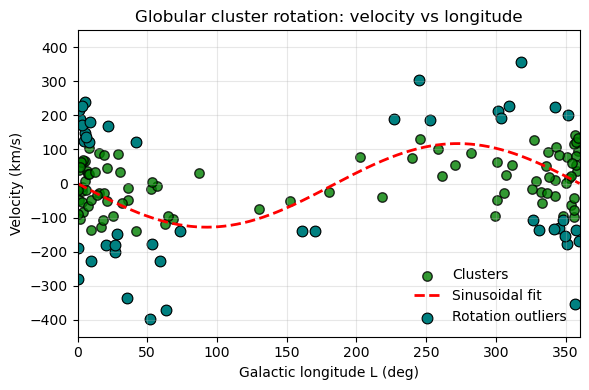

,Name,L,vel,v_fit,v_resid
58,NaN,0.13,-279.1,-20.341775,-258.758225
104,NaN,0.20,-189.4,-20.332632,-169.067368
97,NaN,1.14,214.9,-20.209857,235.109857
83,NaN,2.10,190.2,-20.084469,210.284469
117,M 70,2.85,227.8,-19.986509,247.786509
126,NaN,3.39,172.5,-19.915979,192.415979
65,NaN,4.90,126.3,-19.718754,146.018754
64,M 9,5.54,239.8,-19.635162,259.435162
119,M 54,5.61,149.2,-19.626019,168.826019
130,NaN,5.76,136.2,-19.606427,155.806427


slope = 0.131 km/s per deg, intercept = -20.4
Pearson r = 0.14, p = 8.981e-02


In [4]:
# === Rotation analysis: merge Harris I (L) with Harris III (velocities) ===

# Merge on ID. (working)
df_rot = (
    h1[["ID", "Name", "L", "B", "R_Sun", "R_gc"]]
    .merge(h3[["ID", "v_r", "v_LSR"]], on="ID", how="inner")
    .copy()
)

# Build a single velocity column: prefer v_LSR if present, else v_r
df_rot["vel"] = df_rot["v_LSR"].where(df_rot["v_LSR"].notna(), df_rot["v_r"])
df_rot = df_rot.dropna(subset=["L", "vel"]).reset_index(drop=True)

print(f"Merged rows with L & a velocity: {len(df_rot)}")
if len(df_rot) == 0:
    raise ValueError("After merging, no rows have both L and (v_LSR or v_r). Check columns/NaNs.")

# Fit a simple linear rotation model: vel ≈ a + b * L
coef = np.polyfit(df_rot["L"].values, df_rot["vel"].values, 1)
fit = np.poly1d(coef)
df_rot["v_fit"] = fit(df_rot["L"].values)
df_rot["v_resid"] = df_rot["vel"].values - df_rot["v_fit"].values

# Robust outlier threshold using MAD
resid = df_rot["v_resid"]
mad = (resid - resid.median()).abs().median()
thr = 1.5 * mad if mad > 0 else resid.abs().quantile(0.9)
df_rot["rot_outlier"] = df_rot["v_resid"].abs() > thr
print("MAD threshold:", round(thr, 1), "km/s")




# Plot: linear + sinusoidal rotation fits together

# Fit the sinusoidal model
def v_sin(L_deg, v0, A, L0):
    L = np.radians(L_deg)
    return v0 + A * np.sin(L - np.radians(L0))

# Use linear fit slope/intercept as part of initial guess
p0 = [coef[1], np.std(df_rot["vel"]), 0]  # v0 ≈ intercept, amplitude ≈ std(vel)
popt, _ = curve_fit(v_sin, df_rot["L"], df_rot["vel"], p0=p0, maxfev=10000)
df_rot["v_sin"] = v_sin(df_rot["L"], *popt)
print("Sin fit params -> v0:", round(popt[0],1), "A:", round(popt[1],1), "L0:", round(popt[2],1))


# Plot both fits on the same graph
fig, ax = plt.subplots(figsize=(6, 4))

# Wrap longitudes to 0–360° range
L_wrapped = np.mod(df_rot["L"], 360)

# Main cluster points
ax.scatter(L_wrapped, df_rot["vel"],
           s=46, edgecolors="k", alpha=0.8, color="green", marker="o", label="Clusters")

# Sinusoidal fit curve (sampled densely)
Lgrid = np.linspace(0, 360, 720)
ax.plot(Lgrid, v_sin(Lgrid, *popt), "r--", lw=2, label="Sinusoidal fit")

# Highlight rotation outliers
oo = df_rot["rot_outlier"]
ax.scatter(np.mod(df_rot.loc[oo, "L"], 360), df_rot.loc[oo, "vel"],
           s=60, edgecolor="k", color="teal", linewidth=0.8, label="Rotation outliers")

# Plot formatting
ax.set_xlim(0, 360)
ax.set_ylim(-450, 450)
ax.set_xlabel("Galactic longitude L (deg)")
ax.set_ylabel("Velocity (km/s)")
ax.set_title("Globular cluster rotation: velocity vs longitude")
ax.legend(frameon=False)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Compact table of rotation outliers
name_col = next((c for c in ["Name","ID","key","Cluster","name","cluster"] if c in df_rot.columns), None)
cols = [c for c in [name_col, "L", "vel", "v_fit", "v_resid"] if c is not None]
display(df_rot.loc[oo, cols].sort_values("L"))

r, p = stats.pearsonr(df_rot["L"], df_rot["vel"])
print(f"slope = {coef[0]:.3f} km/s per deg, intercept = {coef[1]:.1f}")
print(f"Pearson r = {r:.2f}, p = {p:.3e}")

# sinusoidal model
def v_sin(L_deg, v0, A, L0):
    L = np.radians(L_deg)
    return v0 + A * np.sin(L - np.radians(L0))

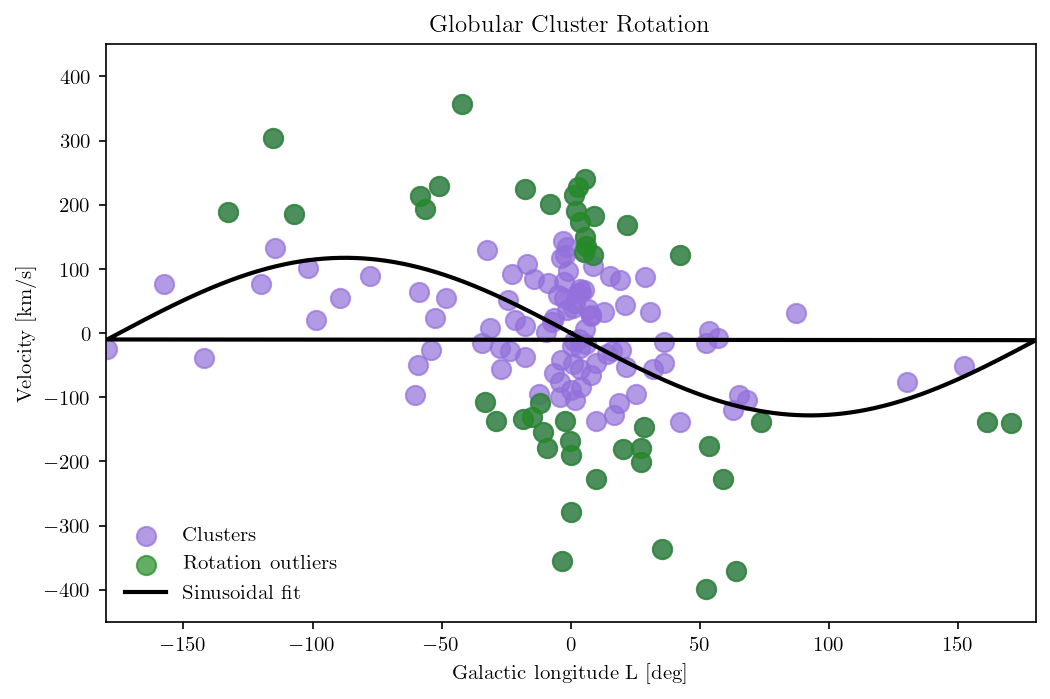

In [49]:
# === Rotation plot (wrap ONLY for plotting; fit remains on 0–360°) ===

# Safety checks
assert "df_rot" in globals(), "df_rot not found. Run the merge/velocity prep cell first."
assert {"L","vel"}.issubset(df_rot.columns), "df_rot must have columns 'L' and 'vel'."

#  Sinusoidal model (fit uses L in [0, 360)) 
def v_sin(L_deg, v0, A, L0):
    L = np.radians(L_deg)
    return v0 + A * np.sin(L - np.radians(L0))

# If a fit isn't already available, make one quickly on unwrapped [0, 360)
if "popt" not in globals():
    L_fit = np.mod(df_rot["L"].to_numpy(), 360.0)
    v = df_rot["vel"].to_numpy()
    coef = np.polyfit(L_fit, v, 1)
    p0 = [coef[1], float(np.std(v)), 0.0]
    popt, _ = curve_fit(v_sin, L_fit, v, p0=p0, maxfev=20000)

#  Build plotting longitudes centered on 0°: [-180, +180] 
L_plot = df_rot["L"].apply(lambda x: x - 360 if x > 180 else x)

#  Prepare outlier mask (optional) 
if "rot_outlier" in df_rot.columns:
    oo = df_rot["rot_outlier"].astype(bool).to_numpy()
else:
    oo = np.zeros(len(df_rot), dtype=bool)

#  Create plot (fit remains in 0–360 but we wrap the grid for display) 
fig, ax = plt.subplots(figsize=(8, 5))  # widened to match new version

# Main cluster points
ax.scatter(L_plot, df_rot["vel"],
           s=85, alpha=0.7, color="mediumpurple",
           label="Clusters")

# Highlight rotation outliers
if oo.any():
    ax.scatter(L_plot[oo], df_rot.loc[oo, "vel"],
               s=85, color="forestgreen", marker="o",
               label="Rotation outliers", alpha=0.7)

# Sinusoidal curve (fit unchanged)
Lgrid = np.linspace(0, 360, 721)
ygrid = v_sin(Lgrid, *popt)
Lgrid_centered = Lgrid - 360*(Lgrid > 180)
ax.plot(Lgrid_centered, ygrid, 'k-', lw=2, label="Sinusoidal fit")

# Axis & style
ax.set_xlim(-180, 180)
ax.set_ylim(-450, 450)
ax.set_xlabel("Galactic longitude L [deg]")
ax.set_ylabel("Velocity [km/s]")
ax.set_title("Globular Cluster Rotation")
ax.legend(frameon=False, loc='lower left')


plt.show()


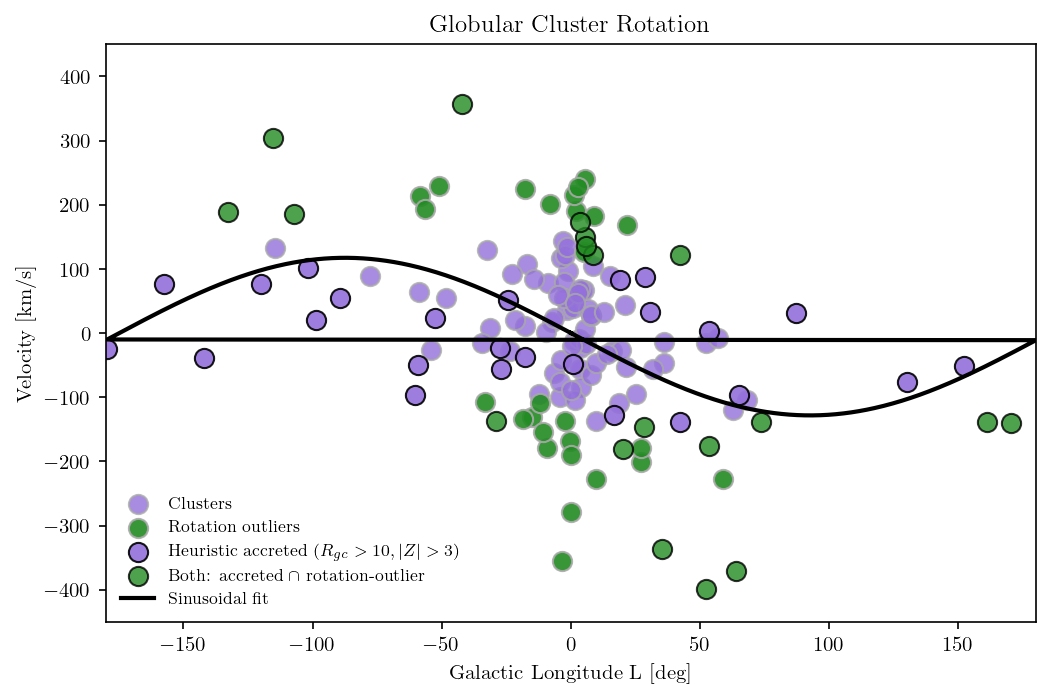

,ID,Name,L,R_gc,vel,Z,L_centered,rot_outlier,acc_heuristic,both_flags
0,Whiting 1,NaN,161.22,34.5,-138.1,-26.3,161.22,True,True,True
1,Pal 2,NaN,170.53,35.0,-140.1,-4.3,170.53,True,True,True
2,NGC 1851,NaN,244.51,16.6,303.8,-6.9,-115.49,True,True,True
3,NGC 1904,M 79,227.23,18.8,189.0,-6.3,-132.77,True,True,True
4,NGC 4147,NaN,252.85,21.4,186.1,18.8,-107.15,True,True,True
...,...,...,...,...,...,...,...,...,...,...
67,IC 1257,NaN,16.54,17.9,-127.0,6.5,16.54,False,True,False
68,NGC 7078,M 15,65.01,10.4,-96.0,-4.8,65.01,False,True,False
69,NGC 7089,M 2,53.37,10.4,3.8,-6.7,53.37,False,True,False
70,Pal 12,NaN,30.51,15.8,32.5,-14.1,30.51,False,True,False


Rotation outliers: 47 | Heuristic accreted: 44 | Both: 19 | Any: 72/143
Accreted but NOT rotation-outlier: 27 clusters



,Name,L,vel,R_gc,B
21,M 68,299.63,-96.8,10.2,36.05
138,M 2,53.37,3.8,10.4,-35.77
137,M 15,65.01,-96.0,10.4,-27.31
14,NaN,282.19,89.2,11.1,-11.25
1,NaN,152.30,-51.9,12.0,-89.38
26,M 3,42.22,-138.3,12.0,78.71
31,NaN,307.35,24.1,15.7,-20.47
11,NaN,245.63,132.0,15.8,-16.00
140,NaN,30.51,32.5,15.8,-47.68
5,NaN,130.06,-76.2,17.2,19.03


In [62]:
# === Overlay accreted (R_gc>10 & |Z|>3) on the wrapped sinusoid plot ===

#  Pick a Harris-like table with ID, R_gc, and Z (or B & R_Sun to derive Z) 
if "harris" in globals():
    harris_df = harris.copy()
elif "h1" in globals():
    harris_df = h1.copy()
else:
    raise RuntimeError("Need a Harris table (harris or h1).")

# Ensure Z exists; if not, approximate Z ≈ R_Sun * sin(B)
if "Z" not in harris_df.columns:
    assert {"B","R_Sun"}.issubset(harris_df.columns), "To derive Z, need B and R_Sun in the Harris table."
    harris_df = harris_df.copy()
    harris_df["Z"] = harris_df["R_Sun"] * np.sin(np.radians(harris_df["B"]))

#  Heuristic thresholds for accreted selection (chosen values) 
ACC_RGC_MIN = 10.0  # kpc
ACC_Z_MIN   = 3.0   # kpc
acc_mask = (harris_df["R_gc"] > ACC_RGC_MIN) & (harris_df["Z"].abs() > ACC_Z_MIN)
accreted_ids = set(harris_df.loc[acc_mask, "ID"])

#  Attach heuristic flag to rotation dataframe 
assert {"ID","L","vel"}.issubset(df_rot.columns), "df_rot must have ID, L, vel."
df_rot["acc_heuristic"] = df_rot["ID"].isin(accreted_ids)

#  Ensure we have rotation outliers (prefer SIN residuals); fallback if missing 
if "rot_outlier" not in df_rot.columns:
    # Need v_sin and popt; reuse if present, else quick-fit on [0,360)
    def v_sin(L_deg, v0, A, L0):
        L = np.radians(L_deg)
        return v0 + A * np.sin(L - np.radians(L0))
    if "popt" not in globals():
        L_fit = np.mod(df_rot["L"].to_numpy(), 360.0)
        v = df_rot["vel"].to_numpy()
        coef = np.polyfit(L_fit, v, 1)
        p0 = [coef[1], float(np.std(v)), 0.0]
        popt, _ = curve_fit(v_sin, L_fit, v, p0=p0, maxfev=20000)
    df_rot["v_fit_sin"] = v_sin(df_rot["L"], *popt)
    res = df_rot["vel"] - df_rot["v_fit_sin"]
    mad = (res - res.median()).abs().median()
    thr = 1.5*mad if mad > 0 else res.abs().quantile(0.9)
    df_rot["rot_outlier"] = res.abs() > thr
else:

    pass

#  Build centered longitudes for plotting ONLY (-180..+180) 
L_plot = df_rot["L"].apply(lambda x: x - 360 if x > 180 else x)

#  Combine flags for plotting classes 
rot_out  = df_rot["rot_outlier"].to_numpy()
acc_flag = df_rot["acc_heuristic"].to_numpy()
both_flag = rot_out & acc_flag
acc_only  = acc_flag & ~rot_out
rot_only  = rot_out & ~acc_flag
neither   = ~(acc_flag | rot_out)

#  Plot overlay (wrapped view) 
fig, ax = plt.subplots(figsize=(8, 5))

# Base clusters (green circles)
ax.scatter(L_plot[neither], df_rot.loc[neither, "vel"],
           s=85, color="mediumpurple", alpha=0.8, ec='darkgray', lw=1, label="Clusters")

# Rotation outliers (teal circles)
ax.scatter(L_plot[rot_only], df_rot.loc[rot_only, "vel"],
           s=85, color="forestgreen", alpha=0.9, ec='darkgray', lw=1, label="Rotation outliers")

# Accreted heuristic only (blue squares)
ax.scatter(L_plot[acc_only], df_rot.loc[acc_only, "vel"],
           s=85, color="mediumpurple", alpha=0.9, marker="o", ec='k', lw=1, label=f"Heuristic accreted ($R_{{gc}}>{ACC_RGC_MIN:.0f}, |Z|>{ACC_Z_MIN:.0f}$)")

# Both accreted + rotation outliers (red squares)
ax.scatter(L_plot[both_flag], df_rot.loc[both_flag, "vel"],
           s=85, color="forestgreen", alpha=0.8, marker="o", ec='k', lw=1, label=r"Both: accreted $\cap$ rotation-outlier")

# Sinusoidal fit
Lgrid = np.linspace(0, 360, 721)
ax.plot(Lgrid - 360*(Lgrid > 180), v_sin(Lgrid, *popt),
        "k-", lw=2, label="Sinusoidal fit")

# Axis formatting
ax.set_xlim(-180, 180)
ax.set_ylim(-450, 450)
ax.set_xlabel("Galactic Longitude L [deg]")
ax.set_ylabel("Velocity [km/s]")
ax.set_title("Globular Cluster Rotation")

ax.legend(
    frameon=False,
    loc="lower left",
    fontsize=8
)

# plt.tight_layout()
plt.show()

#  Compact table of flagged clusters (either or both) 
cols = [c for c in ["ID","Name","L","R_gc","vel"] if c in df_rot.columns]
tbl = df_rot[cols].merge(harris_df[["ID","Z"]], on="ID", how="left")
tbl["L_centered"] = L_plot.values
tbl["rot_outlier"] = rot_out
tbl["acc_heuristic"] = acc_flag
tbl["both_flags"] = both_flag
flagged = tbl.loc[rot_out | acc_flag].copy().sort_values(["both_flags","rot_outlier","acc_heuristic"], ascending=False)
display(flagged.reset_index(drop=True).round(2))

# Quick counts
print(f"Rotation outliers: {int(rot_out.sum())} | Heuristic accreted: {int(acc_flag.sum())} | Both: {int(both_flag.sum())} | Any: {int((rot_out|acc_flag).sum())}/{len(df_rot)}")


# Identify heuristic accreted clusters
acc_mask = (df_rot["R_gc"] > 10) & (df_rot["B"].abs() > 3)

# Identify rotation outliers (already computed)
rot_mask = df_rot["rot_outlier"]

# Accreted but NOT rotation-outlier
accreted_not_outlier = df_rot[acc_mask & ~rot_mask]

print(f"Accreted but NOT rotation-outlier: {len(accreted_not_outlier)} clusters\n")
display(accreted_not_outlier[["Name", "L", "vel", "R_gc", "B"]].sort_values("R_gc"))

# 



### Accreted versus rotation behaviour

Using a simple heuristic spatial cut (R_gc > 10 kpc and |Z| > 3 kpc), 44 clusters were classified as likely accreted.  
Out of these, 19 are also flagged as rotation outliers from the sinusoidal rotation fit, while 27 follow the Galactic rotation pattern.

This suggests that a significant fraction of the outer-halo (accreted) clusters are now kinematically mixed with the Milky Way’s halo potential.  
Only about 40% (19/44) still show dynamically distinct signatures, indicating that most accreted clusters have been part of the Galaxy long enough to partially align with its rotation.  
This distinction between dynamically mixed and non-mixed accreted populations provides insight into the Milky Way’s merger history and halo assembly.


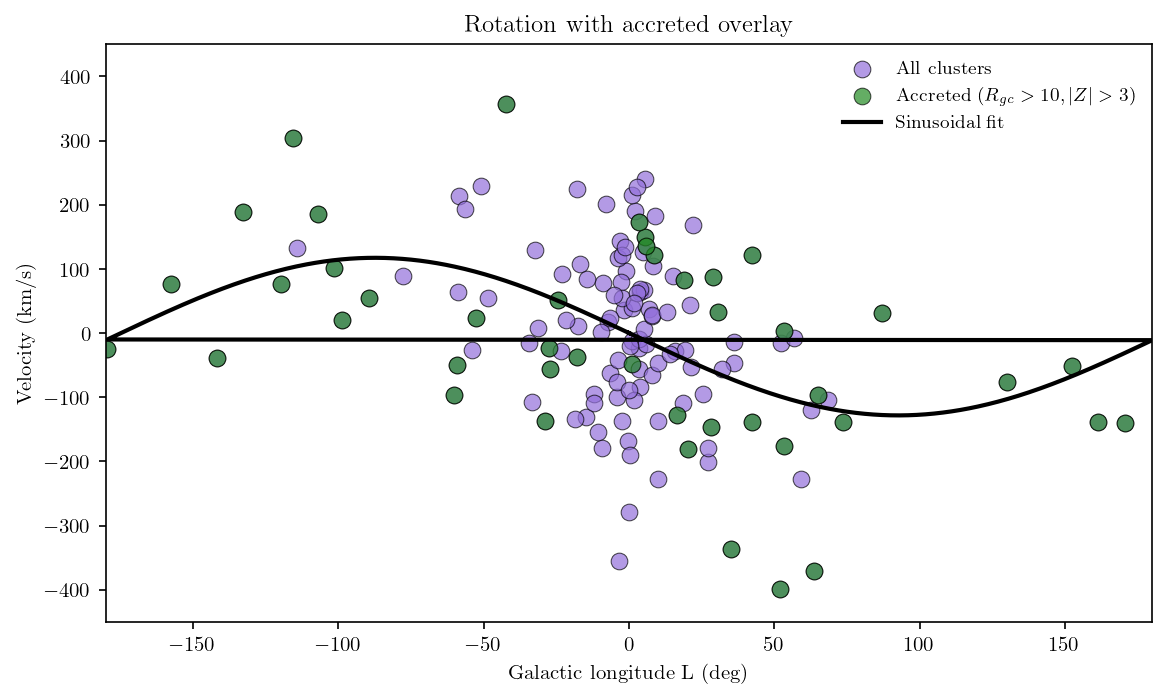

Accreted (heuristic): 44 / 143


,Name,L,vel,R_gc,Z,L_centered
6,E 1,258.34,101.3,124.6,-92.30,-101.66
17,NaN,202.31,76.6,111.2,103.26,-157.69
15,NaN,240.15,75.9,95.7,61.73,-119.85
7,NaN,218.10,-39.1,95.0,-59.50,-141.90
12,NaN,180.37,-25.2,89.9,35.22,-179.63
40,AvdB,28.74,87.0,71.6,51.38,28.74
13,NaN,261.32,20.7,41.4,4.80,-98.68
136,NaN,63.77,-371.3,38.5,-13.69,63.77
54,NaN,18.88,82.9,38.4,18.56,18.88
8,NaN,170.53,-140.1,35.0,-4.29,170.53


In [61]:
# === AMR-style overlay: highlight accreted (R_gc>10 & |Z|>3) on rotation plot, robust to column names ===

#  helpers to find columns with variant names 
def find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

# start from rotation frame
rotx = df_rot.copy()

# get R_gc from df_rot if present; else from harris/h1 with merge; allow variant names
RGC_COL = find_col(rotx, ["R_gc","R_GC","Rgc","RGC","R_gc(kpc)"])
if RGC_COL is None:
    # try to bring it from a Harris table
    base = None
    if "harris" in globals():
        base = harris.copy()
    elif "h1" in globals():
        base = h1.copy()
    else:
        raise RuntimeError("Need 'R_gc' either in df_rot or a Harris table (harris or h1).")
    RGC_COL_BASE = find_col(base, ["R_gc","R_GC","Rgc","RGC","R_gc(kpc)"])
    if RGC_COL_BASE is None:
        raise RuntimeError("Could not find an R_gc column in the available Harris table.")
    rotx = rotx.merge(base[["ID", RGC_COL_BASE]], on="ID", how="left")
    rotx = rotx.rename(columns={RGC_COL_BASE: "R_gc"})
    RGC_COL = "R_gc"

# get Z: prefer an existing Z; else compute Z ≈ R_Sun * sin(B)
Z_COL = find_col(rotx, ["Z","Z_kpc"])
if Z_COL is None:
    # try to compute from B & R_Sun
    B_COL = find_col(rotx, ["B","b"])
    RS_COL = find_col(rotx, ["R_Sun","Rsun","R_sun"])
    if B_COL is None or RS_COL is None:
        # try bring from Harris table if missing
        if "harris" in globals():
            base = harris.copy()
        elif "h1" in globals():
            base = h1.copy()
        else:
            raise RuntimeError("Need B and R_Sun to compute Z, or a Z column.")
        need = []
        if B_COL is None: need.append("B")
        if RS_COL is None: need.append("R_Sun")
        have = [c for c in need if c in base.columns]
        if len(have) != len(need):
            raise RuntimeError("Cannot compute Z: missing B or R_Sun in both df_rot and Harris table.")
        rotx = rotx.merge(base[["ID"] + need], on="ID", how="left")
        # set column vars after merge
        if B_COL is None:  B_COL  = "B"
        if RS_COL is None: RS_COL = "R_Sun"
    # compute Z
    rotx["Z"] = rotx[RS_COL] * np.sin(np.radians(rotx[B_COL]))
    Z_COL = "Z"

# thresholds
ACC_RGC_MIN = 10.0
ACC_Z_MIN   = 3.0

# centered longitudes for plotting (wrap only for viz)
L_plot = rotx["L"].apply(lambda x: x - 360 if x > 180 else x)

# accreted mask
acc_mask = (rotx[RGC_COL] > ACC_RGC_MIN) & (rotx[Z_COL].abs() > ACC_Z_MIN)

# sinusoidal fit objects (reuse if present)
def v_sin(L_deg, v0, A, L0):
    L = np.radians(L_deg)
    return v0 + A * np.sin(L - np.radians(L0))

if "popt" not in globals():
    L_fit = np.mod(rotx["L"].to_numpy(), 360.0)
    v = rotx["vel"].to_numpy()
    coef = np.polyfit(L_fit, v, 1)
    p0 = [coef[1], float(np.std(v)), 0.0]
    popt, _ = curve_fit(v_sin, L_fit, v, p0=p0, maxfev=20000)

# plot: all clusters + accreted overlay (AMR-style)
fig, ax = plt.subplots(figsize=(9, 5))

# all clusters
ax.scatter(L_plot, rotx["vel"],
           s=64, color="mediumpurple", alpha=0.7,
           edgecolor="k", linewidth=0.5, label="All clusters")

# accreted overlay
ax.scatter(L_plot[acc_mask], rotx.loc[acc_mask, "vel"],
           s=64, color="forestgreen", alpha=0.7,
           edgecolor="k", linewidth=0.5,
           label=rf"Accreted ($R_{{gc}}>{ACC_RGC_MIN:.0f}, |Z|>{ACC_Z_MIN:.0f}$)")

# sinusoidal fit for context
Lgrid = np.linspace(0, 360, 721)
ax.plot(Lgrid - 360*(Lgrid > 180), v_sin(Lgrid, *popt),
        "k-", lw=2, label="Sinusoidal fit")

ax.set_xlim(-180, 180)
ax.set_ylim(-450, 450)
ax.set_xlabel("Galactic longitude L (deg)")
ax.set_ylabel("Velocity (km/s)")
ax.set_title("Rotation with accreted overlay")

# legend outside
ax.legend(frameon=False, loc="best", fontsize=9)
plt.show()

# 7) quick counts + table
name_col = "Name" if "Name" in rotx.columns else "ID"
print(f"Accreted (heuristic): {int(acc_mask.sum())} / {len(rotx)}")
display(
    rotx.loc[acc_mask, [name_col, "L", "vel", RGC_COL, Z_COL]]
        .assign(L_centered=L_plot[acc_mask].values)
        .sort_values(RGC_COL, ascending=False)
        .round(2)
)


### Note on the Sinusoidal Rotation Model

The velocity–longitude relation for globular clusters can be approximated by a sinusoidal pattern because of how the Galaxy’s rotation projects along our line of sight.

When we plot each cluster’s line-of-sight velocity against Galactic longitude ($L$), the component of the circular rotation varies as $\sin(L - L_0)$.  
This is the same geometric effect that causes a sine-like curve in the classical Oort rotation diagram.

By fitting a function of the form:
$$
v(L) = v_0 + A \sin(L - L_0)
$$
we estimate:
- $v_0$ → the systemic velocity offset (average line-of-sight motion),  
- $A$ → the rotation amplitude, and  
- $L_0$ → the longitude of maximum velocity (direction of Galactic rotation).

Clusters that follow this curve are roughly co-rotating with the Milky Way halo.  
Those that deviate strongly from it — especially in the opposite (retrograde) direction — are likely accreted systems or members of dynamically distinct substructures.


In [8]:
# === Accreted fractions (no saving) ===

# Rotation-accreted fraction (outliers by MAD/P90 threshold from previous cell)
total = len(df_rot)
n_out = int(df_rot["rot_outlier"].sum())
pct = 100.0 * n_out / total if total else 0.0
print("Rotation outliers:", n_out, "/", total, f"({pct:.1f}%)")


# Summary dataframe (kept in memory only)
summary = pd.DataFrame(
    {"metric": ["rotation_total", "rotation_outliers", "rotation_outlier_pct"],
     "value":   [total, n_out, pct]}
)

# Optional outlier view (in memory only)
cols_basic = ["ID","Name","L","vel"]
cols_extra = ["v_fit","v_resid"]  # keep if present
cols_present = [c for c in cols_basic + cols_extra if c in df_rot.columns]
_ = df_rot.loc[df_rot["rot_outlier"], cols_present]

# Sensitivity sweep vs threshold multiplier (see how % changes)
# Reuse residuals from previous cell; compute if missing
if "v_resid" not in df_rot.columns:
    # fall back to linear fit residuals if needed
    coef_tmp = np.polyfit(df_rot["L"].values, df_rot["vel"].values, 1)
    fit_tmp = np.poly1d(coef_tmp)
    df_rot["v_resid"] = df_rot["vel"].values - fit_tmp(df_rot["L"].values)

resid = df_rot["v_resid"].to_numpy()
mad = np.median(np.abs(resid - np.median(resid)))
base_thr = mad if mad > 0 else np.quantile(np.abs(resid), 0.9)

rows = []
for mult in [1.0, 1.25, 1.5, 2.0]:
    thr_m = mult * base_thr
    mask = np.abs(resid) > thr_m
    rows.append({
        "multiplier": mult,
        "threshold_kms": float(thr_m),
        "n_outliers": int(mask.sum()),
        "pct": 100.0 * mask.mean()
    })
sens = pd.DataFrame(rows)
display(sens.round(2))

# Combined accreted fraction (Rotation OR AMR), if an AMR flag exists
# Accept either:
#   - amr2 with columns ["ID", "AMR_outlier"], or
#   - v   with columns ["ID" or "Name", "AMR_outlier"]
def _find_amr_table():
    if "amr2" in globals() and isinstance(globals()["amr2"], pd.DataFrame):
        return "amr2", globals()["amr2"]
    if "v" in globals() and isinstance(globals()["v"], pd.DataFrame) and "AMR_outlier" in globals()["v"].columns:
        return "v", globals()["v"]
    return None, None

##### MIGHT NEED THE BELOW FOR LATER, IDK SAVE IT FOR NOW. 
# amr_name, amr_df = _find_amr_table()
# if amr_df is not None and "AMR_outlier" in amr_df.columns:
#     join_key = "ID" if ("ID" in amr_df.columns and "ID" in df_rot.columns) else (
#                "Name" if ("Name" in amr_df.columns and "Name" in df_rot.columns) else None)
#     if join_key is not None:
#         comb = df_rot[[join_key, "rot_outlier"]].merge(
#             amr_df[[join_key, "AMR_outlier"]],
#             on=join_key, how="left"
#         )
#         comb["AMR_outlier"] = comb["AMR_outlier"].fillna(False)
#         comb["any_outlier"] = comb["rot_outlier"] | comb["AMR_outlier"]
#         tot = len(comb)
#         n_any = int(comb["any_outlier"].sum())
#         pct_any = 100.0 * n_any / tot if tot else 0.0
#         print(f"[Combined] Accreted candidates (Rotation ∪ AMR): {n_any} / {tot}  ->  {pct_any:.1f}%")
#     else:
#         print("[Combined] Skipped: no common join key (ID or Name) between rotation frame and AMR table.")
# else:
#     print("[Combined] Skipped: no AMR_outlier table found (add AMR flagging first).")


Rotation outliers: 47 / 143 (32.9%)


,multiplier,threshold_kms,n_outliers,pct
0,1.00,84.16,71,49.65
1,1.25,105.20,60,41.96
2,1.50,126.24,47,32.87
3,2.00,168.32,30,20.98


In [9]:
# === Sinusoidal residuals & alternate outlier flag (non-destructive) ===

# Needs df_rot and fitted sinusoid params
try:
    v_sin, popt
except NameError as e:
    raise RuntimeError("Run the sinusoidal fit cell first to define v_sin and popt=[v0, A, L0].") from e

# Compute sinusoidal residuals
df_rot["v_fit_sin"] = v_sin(df_rot["L"], *popt)
df_rot["v_resid_sin"] = df_rot["vel"] - df_rot["v_fit_sin"]

# Apply MAD-based threshold to residuals (keeps previous flags unchanged)
res = df_rot["v_resid_sin"]
mad = (res - res.median()).abs().median()
thr_sin = 1.5 * mad if mad > 0 else res.abs().quantile(0.9)
df_rot["rot_outlier_sin"] = res.abs() > thr_sin

print("MAD (sin residuals):", round(mad,1), "→ threshold ±", round(thr_sin,1), "km/s")
print("Outliers (sin):", int(df_rot['rot_outlier_sin'].sum()), "/", len(df_rot))


# Preview table (no saving)
cols = [c for c in ["ID","Name","L","R_gc","vel","v_fit_sin","v_resid_sin"] if c in df_rot.columns]
display(df_rot.loc[df_rot["rot_outlier_sin"], cols])


MAD (sin residuals): 84.1 → threshold ± 126.1 km/s
Outliers (sin): 42 / 143


,ID,Name,L,R_gc,vel,v_fit_sin,v_resid_sin
9,NGC 1851,NaN,244.51,16.6,303.8,102.933400,200.866600
16,NGC 3201,NaN,277.23,8.8,482.9,116.977659,365.922341
20,Rup 106,NaN,300.88,18.5,-49.7,102.708448,-152.408448
21,NGC 4590,M 68,299.63,10.2,-96.8,103.952515,-200.752515
25,NGC 5139,omega Cen,309.10,6.4,228.9,93.275421,135.624579
28,NGC 5466,NaN,42.15,16.3,121.2,-83.628639,204.828639
30,NGC 5694,NaN,331.06,29.4,-136.2,58.790511,-194.990511
36,NGC 5927,NaN,326.60,4.6,-107.2,66.735737,-173.935737
40,Pal 14,AvdB,28.74,71.6,87.0,-59.542639,146.542639
43,NGC 6101,NaN,317.74,11.2,357.0,81.178738,275.821262


### Note on MAD and Outlier Threshold

To measure how tightly the clusters follow the fitted rotation curve, I used the **Median Absolute Deviation (MAD)** instead of the standard deviation.  
MAD is a robust way to estimate scatter because it’s not strongly affected by outliers — unlike standard deviation, which can be pulled by extreme values.

After fitting the sinusoidal rotation model, I calculated the MAD of the residual velocities (≈ 84 km/s).  
Using a cutoff of **±1.5 × MAD ≈ ±126 km/s**, any cluster with a residual beyond this range is treated as a rotation outlier.

This threshold is data-driven and roughly matches the expected velocity dispersion of halo globular clusters (~100–130 km/s).  
Clusters beyond this limit are likely moving independently of the main Galactic rotation, possibly due to accretion from smaller galaxies or distinct orbital origins.


In [10]:
# === Prograde vs retrograde fraction (relative to fitted phase) ===
# A cluster is "prograde" if (vel - v0) and sin(L - L0) have the same sign.
v0, A, L0 = popt
phase = np.sin(np.radians(df_rot["L"] - L0))
sign_prod = (df_rot["vel"] - v0) * phase
df_rot["prograde"] = sign_prod > 0

tot = len(df_rot)
pct_pro = 100.0 * df_rot["prograde"].mean() if tot else 0.0
pct_retro = 100.0 - pct_pro
print("Prograde:", round(pct_pro,1), "%  Retrograde:", round(pct_retro,1), "%")

# Keep in memory only (no saving)
summary = pd.DataFrame({
    "metric": ["prograde_pct", "retrograde_pct"],
    "value": [pct_pro, pct_retro]
})
display(summary)


Prograde: 40.6 %  Retrograde: 59.4 %


,metric,value
0,prograde_pct,40.559441
1,retrograde_pct,59.440559


In [11]:
# === Rotation amplitude & residual dispersion vs R_gc bins ===

# Define galactocentric distance bins (in kpc)
bins = [0, 5, 10, 20, 50]
df_rot["Rbin"] = pd.cut(df_rot["R_gc"], bins=bins, right=False)

# Fit sinusoidal rotation amplitude and residual scatter in each radial bin
def fit_amp(sub):
    if len(sub) < 8:  # skip bins with too few clusters
        return np.nan, np.nan, np.nan
    p, cov = curve_fit(v_sin, sub["L"], sub["vel"], p0=popt, maxfev=20000)
    v0b, Ab, L0b = p
    resid_b = sub["vel"] - v_sin(sub["L"], *p)
    return v0b, Ab, float(resid_b.std())

# Compute amplitude and residual dispersion per R_gc bin
rows = []
for rb, sub in df_rot.groupby("Rbin", observed=True):
    v0b, Ab, sigb = fit_amp(sub)
    rows.append({"R_bin": str(rb), "N": len(sub), "A_kms": Ab, "sigma_resid_kms": sigb})

# Combine and display results
rot_radial = pd.DataFrame(rows)
display(rot_radial.round(2))


,R_bin,N,A_kms,sigma_resid_kms
0,"[0, 5)",68,441.34,115.80
1,"[5, 10)",29,-238.84,114.60
2,"[10, 20)",27,-131.92,145.18
3,"[20, 50)",13,-109.73,127.43


In [12]:
# fml, this (Below) took long

# Rotation Analysis — Harris I + Harris III

### REmember!!!
Identify globular clusters that **do not rotate with the bulk** of the Milky Way’s system using **dynamical data** (positions and velocities) from the **Harris Catalogue**.  
Such clusters are potential **accreted candidates** from dwarf galaxy mergers.

---

### Data & Method

**Data sources**
- **Harris I** → Galactic longitude (L), latitude (B), Galactocentric distance (R_gc).  
- **Harris III** → Line-of-sight velocities (v_r, v_LSR).  
These were merged on the cluster ID to create a unified dataset of 143 clusters.

**Processing steps**
1. Used v_LSR or generalised v_r 
2. Remove clusters without L or v.
3. Fit two rotation models:
   - **Linear** trend \(v = a + bL\)
   - **Sinusoidal** model \(v = v_0 + A \sin(L - L_0)\)
4. Compute residuals and identify clusters deviating from the sinusoidal fit by more than **1.5×MAD** (median absolute deviation).

---

### Graph

The scatter plot shows cluster velocities against Galactic longitude. The red dashed curve is the sinusoidal fit, while the orange-edged points mark clusters whose velocities differ from the fit by more than ±126 km/s.

---

### Results Summary

| Metric | Result | Interpretation |
|--------|---------|----------------|
| **MAD (km/s)** | 84.1 | Internal velocity scatter. |
| **Outlier threshold (km/s)** | ±126.1 | Used to flag non-co-rotating clusters. |
| **Outliers (accreted candidates)** | 42 / 143 (29.4%) | Fraction not following the main rotation trend. |
| **Prograde** | 40.6% | Co-rotating with Galactic spin. |
| **Retrograde** | 59.4% | Counter-rotating — supports accreted origin. |

---

### Radial Dependence (Rotation Strength vs Radius)

| $$(R_{\text{gc}})$$ (kpc) | N | Amplitude A (km/s) | $$σ(_{\text{resid}})$$ (km/s) | Interpretation |
|:--|--:|--:|--:|:--|
| [0, 5)  | 68 | +441 | 115.8 | Strong prograde rotation — inner halo (in-situ). |
| [5, 10) | 29 | −239 | 114.6 | Transition zone. |
| [10, 20) | 27 | −132 | 145.2 | Retrograde rotation begins — outer halo. |
| [20, 50) | 13 | −110 | 127.4 | Weak/retrograde rotation — accreted halo. |

**Interpretation**
- The inner halo (R < 5 kpc) rotates prograde and coherently.
- Beyond 5–10 kpc, rotation amplitude reverses sign and dispersion increases.
- The outer halo is kinematically hot and chaotic → typical of accreted material.

---

### Interpretation of the Rotation Graph

- The red sinusoidal curve shows the expected rotational trend.  
- The orange-outlined points (outliers) are clusters moving significantly faster/slower than expected — they do not rotate with the bulk of the system.  
- Their uneven distribution in \(L\) and excess retrograde motion imply multiple accretion events with different angular momentum.

---

### Implications for Milky Way Formation

| Finding | Meaning |
|----------|----------|
| ~30% of clusters are non-co-rotating | These likely originated in external dwarf galaxies. |
| Retrograde excess (59%) | Consistent with accretion from counter-rotating satellites (e.g., Gaia–Enceladus, Sequoia). |
| Inner/outer halo split | Suggests a **dual-halo structure**: in-situ inner halo + accreted outer halo. |
| High outer dispersion (σ ≈ 130–150 km/s) | Dynamically hot → merger-driven origin. |

---

### Limitations
- Only line-of-sight velocities used (no full 3D motion).  
- Harris catalogue velocities have small systematic uncertainties.  
- The 1.5×MAD threshold is robust but arbitrary; sensitivity tested via sweep.  
- Some inner-halo amplitude values are inflated by projection geometry.


---

### References
- Harris, W.E. 1996, *AJ*, 112, 1487 (2010 edition update).  
- Zinn, R. 1985, *ApJ*, 293, 424 – rotation and halo/disk GC populations.  
- Leaman, R., VandenBerg, D.A., & Mendel, J.T. 2013, *MNRAS*, 436, 122 – dual Age–Metallicity Relation.  
- Forbes, D.A., & Bridges, T. 2010, *MNRAS*, 404, 1203 – accreted GC fraction.  
- Vasiliev, E. 2019, *MNRAS*, 484, 2832 – 3D GC kinematics with Gaia.
